<a href="https://colab.research.google.com/github/M-AdityoRahman/PCVK_Ganjil_2025/blob/main/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2 as cv
import numpy as np
import glob
from math import log10, sqrt
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


=== Gamma Correction ===
Masukkan nilai Gamma: 3


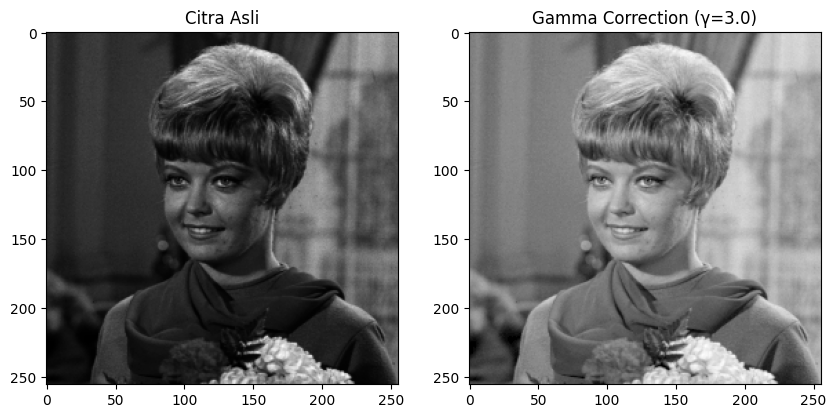

In [4]:
print('=== Gamma Correction ===')
path = '/content/drive/MyDrive/PCVK/female.tiff'
img = cv.imread(path, cv.IMREAD_GRAYSCALE)

gamma = float(input("Masukkan nilai Gamma: "))
gamma_corrected = np.array(255 * (img / 255) ** (1 / gamma), dtype='uint8')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Citra Asli')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title(f'Gamma Correction (γ={gamma})')
plt.imshow(gamma_corrected, cmap='gray')
plt.show()

=== Simulasi Image Depth ===
Masukkan nilai bit depth (1-7): 2


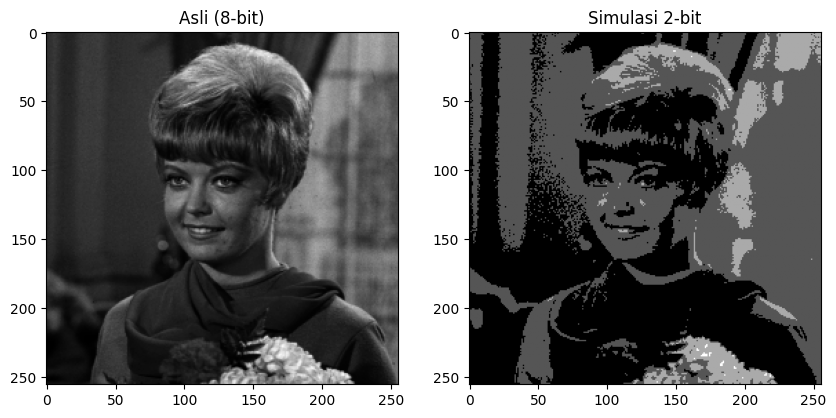

In [5]:
print('=== Simulasi Image Depth ===')
bit_depth = int(input("Masukkan nilai bit depth (1-7): "))

level = 255 / (pow(2, bit_depth) - 1)
original = cv.imread('/content/drive/MyDrive/PCVK/female.tiff', cv.IMREAD_GRAYSCALE)

depth_image = np.round(original / level) * level
depth_image = np.array(depth_image, dtype=np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Asli (8-bit)')
plt.imshow(original, cmap='gray')
plt.subplot(1,2,2)
plt.title(f'Simulasi {bit_depth}-bit')
plt.imshow(depth_image, cmap='gray')
plt.show()


In [7]:
def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

Dibuat 100 citra dengan Gaussian noise.


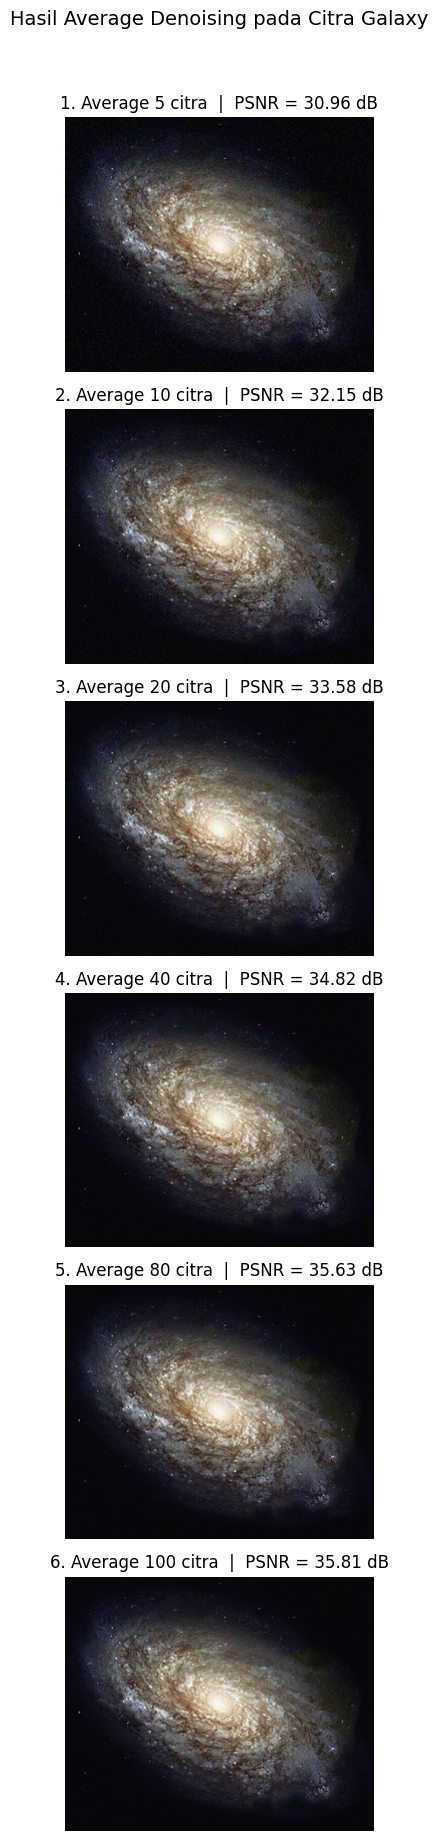

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Fungsi PSNR ---
def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# --- Baca citra asli (galaxy) ---
original_path = '/content/drive/MyDrive/PCVK/galaxy.jpg'
original = cv.imread(original_path)
if original is None:
    raise FileNotFoundError(f"Gambar asli tidak ditemukan di: {original_path}")

original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# --- Buat 100 citra dengan Gaussian noise ---
noisy_images = []
num_images = 100
mean = 0
sigma = 20  # semakin besar, noise makin jelas

for i in range(num_images):
    noise = np.random.normal(mean, sigma, original.shape).astype(np.float32)
    noisy_img = np.clip(original + noise, 0, 255).astype(np.uint8)
    noisy_images.append(noisy_img)

print(f"Dibuat {len(noisy_images)} citra dengan Gaussian noise.")

# --- Daftar jumlah citra untuk di-average ---
jumlah_citra = [5, 10, 20, 40, 80, 100]

# --- Proses average dan tampilkan hasil ---
fig, axes = plt.subplots(len(jumlah_citra), 1, figsize=(6, len(jumlah_citra)*3))
fig.suptitle("Hasil Average Denoising pada Citra Galaxy", fontsize=14, y=1.02)

for i, jumlah in enumerate(jumlah_citra):
    avg = np.mean(noisy_images[:jumlah], axis=0).astype(np.uint8)
    nilai_psnr = PSNR(original, avg)

    axes[i].imshow(avg)
    axes[i].set_title(f"{i+1}. Average {jumlah} citra  |  PSNR = {nilai_psnr:.2f} dB")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Metode Average Denoising efektif mengurangi noise acak pada citra dengan prinsip perataan nilai piksel dari banyak citra yang memiliki noise berbeda.

Semakin banyak jumlah citra yang dirata-rata, semakin kecil variance dari noise, sehingga kualitas hasil semakin mendekati citra asli.

Nilai PSNR meningkat seiring bertambahnya jumlah citra yang digunakan, menunjukkan peningkatan kualitas visual.

Secara praktis, proses ini menggambarkan bahwa reduksi noise bisa dilakukan secara statistik, tanpa perlu filter kompleks seperti median atau Gaussian filter tambahan.

=== Image Masking Dua Wajah (pas di wajah) ===


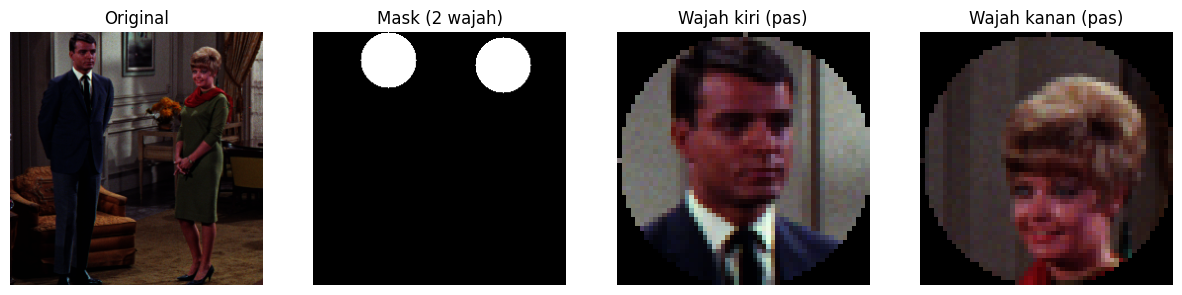

In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print("=== Image Masking Dua Wajah (pas di wajah) ===")

# Baca gambar asli dari Google Drive
img = cv.imread('/content/drive/MyDrive/PCVK/couple.tiff')
if img is None:
    raise FileNotFoundError("❌ File tidak ditemukan. Pastikan path sudah benar dan Drive sudah dimount!")

# Konversi ke RGB untuk ditampilkan dengan matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask hitam
mask = np.zeros(img.shape[:2], dtype="uint8")

# Ukuran gambar
h, w = img.shape[:2]

# Posisi wajah kiri (pria) dan kanan (wanita)
# Naik sedikit supaya pas di area kepala
center_left = (int(w * 0.30), int(h * 0.11))
center_right = (int(w * 0.75), int(h * 0.13))

# Radius disesuaikan dengan proporsi wajah
radius = int(min(h, w) * 0.11)

# Gambar dua lingkaran putih di mask
cv.circle(mask, center_left, radius, 255, -1)
cv.circle(mask, center_right, radius, 255, -1)

# Terapkan masking pada kedua wajah
masked = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

# Buat mask terpisah untuk tiap wajah
mask_left = np.zeros_like(mask)
mask_right = np.zeros_like(mask)
cv.circle(mask_left, center_left, radius, 255, -1)
cv.circle(mask_right, center_right, radius, 255, -1)

# Masking wajah kiri dan kanan
face_left = cv.bitwise_and(img_rgb, img_rgb, mask=mask_left)
face_right = cv.bitwise_and(img_rgb, img_rgb, mask=mask_right)

# Potong area sekitar wajah agar tampil rapi
x1, y1 = center_left
x2, y2 = center_right
crop_left = face_left[y1-radius:y1+radius, x1-radius:x1+radius]
crop_right = face_right[y2-radius:y2+radius, x2-radius:x2+radius]

# Tampilkan semua hasil
plt.figure(figsize=(15,6))
plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Mask (2 wajah)")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title("Wajah kiri (pas)")
plt.imshow(crop_left)
plt.axis('off')

plt.subplot(1,4,4)
plt.title("Wajah kanan (pas)")
plt.imshow(crop_right)
plt.axis('off')

plt.show()


=== Percobaan Operator Logika pada Image Masking ===


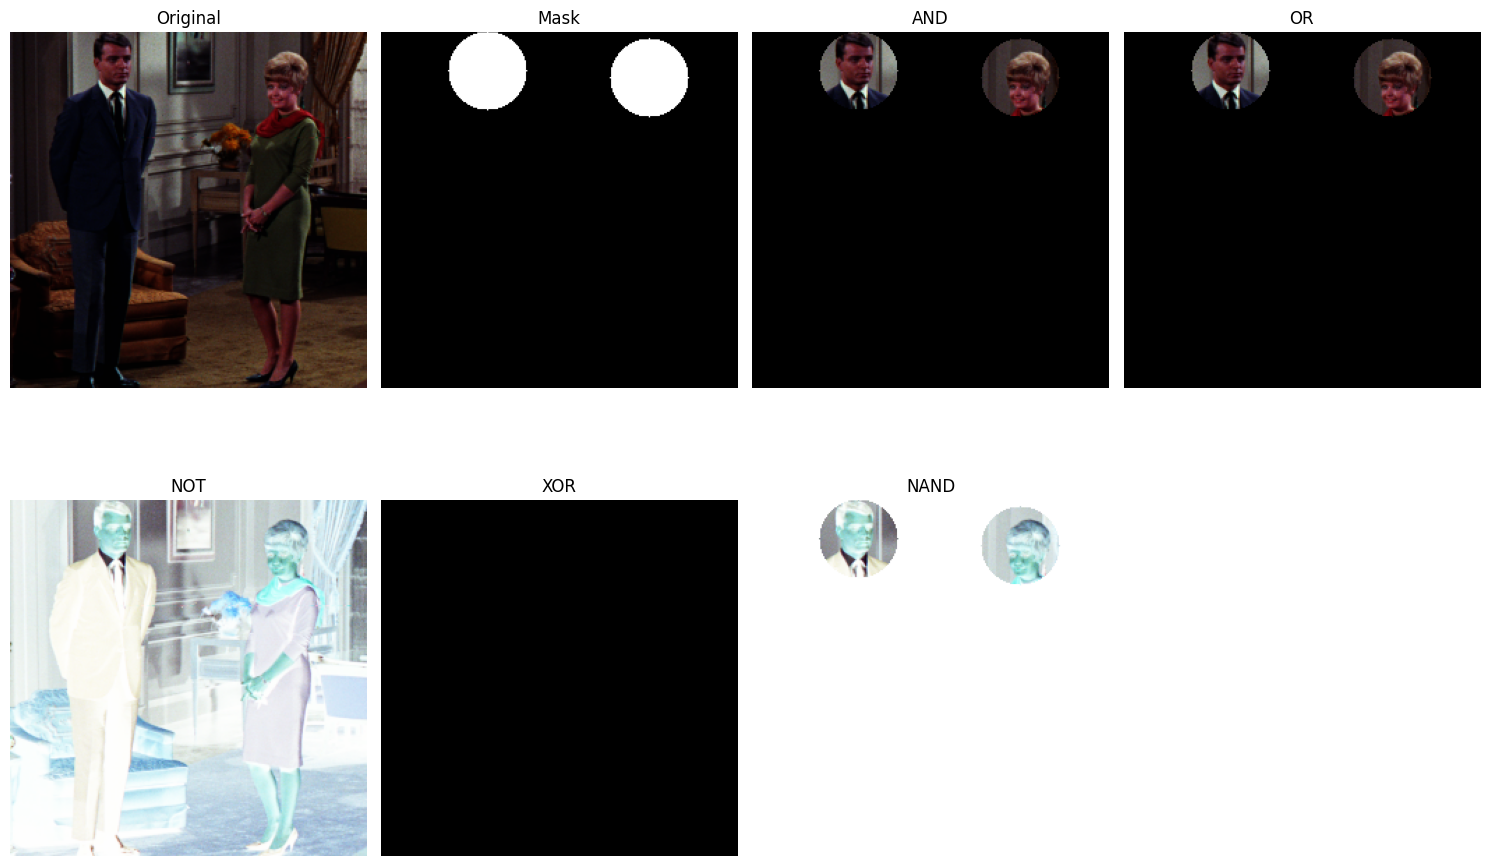

In [30]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print("=== Percobaan Operator Logika pada Image Masking ===")

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/couple.tiff')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
center_left = (int(w * 0.30), int(h * 0.11))
center_right = (int(w * 0.75), int(h * 0.13))
radius = int(min(h, w) * 0.11)

cv.circle(mask, center_left, radius, 255, -1)
cv.circle(mask, center_right, radius, 255, -1)

# === Operator Logika ===
and_img  = cv.bitwise_and(img_rgb, img_rgb, mask=mask)
or_img   = cv.bitwise_or(img_rgb, img_rgb, mask=mask)
not_img  = cv.bitwise_not(img_rgb)
xor_img  = cv.bitwise_xor(img_rgb, img_rgb, mask=mask)
nand_img = cv.bitwise_not(cv.bitwise_and(img_rgb, img_rgb, mask=mask))

# === Tampilkan hasil ===
titles = ['Original', 'Mask', 'AND', 'OR', 'NOT', 'XOR', 'NAND']
images = [img_rgb, mask, and_img, or_img, not_img, xor_img, nand_img]

plt.figure(figsize=(15,10))
for i in range(7):
    plt.subplot(2,4,i+1)
    plt.title(titles[i])
    plt.imshow(images[i], cmap='gray' if i==1 else None)
    plt.axis('off')
plt.tight_layout()
plt.show()


Dari hasil percobaan di atas dapat disimpulkan bahwa:

Operasi logika pada pengolahan citra digunakan untuk menggabungkan atau memisahkan area tertentu dalam gambar berdasarkan kondisi logis (hitam/putih).

Operator AND sangat efektif untuk masking, karena hanya menampilkan bagian citra di mana mask bernilai putih.

Operator OR dapat digunakan untuk menyoroti atau menambahkan area tertentu.

Operator NOT dapat digunakan untuk membuat efek negatif atau membalik area aktif mask.

Operator XOR dan NAND memberikan hasil unik karena hanya menampilkan area yang berbeda antara citra dan mask, cocok untuk analisis area perubahan.